# Pertemuan 12 - Asosiasi Data & Sistem Rekomendasi Dasar
Nama: Widya Anggara
NIM: 230401020091
Kelas: IF401


## Generate & Eksplorasi Dataset

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

produk = [
    'Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
    'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega'
]

transaksi = []

for _ in range(50):
    n_item = np.random.randint(2, 6)

    # Penting: ubah np.str_ menjadi Python str
    item_terpilih = [
        str(x)
        for x in np.random.choice(
            produk,
            n_item,
            replace=False
        )
    ]

    transaksi.append(item_terpilih)

# Suntikkan pola Roti -> Selai
for i in range(20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print('Contoh transaksi:')
for i, t in enumerate(transaksi[:5], start=1):
    print(f'Transaksi {i}: {t}')

print('Jumlah transaksi:', len(transaksi))


Contoh transaksi:
Transaksi 1: ['Keju', 'Roti', 'Mentega', 'Kopi', 'Selai']
Transaksi 2: ['Roti', 'Kopi', 'Teh', 'Selai', 'Mentega']
Transaksi 3: ['Kopi', 'Susu', 'Teh']
Transaksi 4: ['Selai', 'Keju', 'Telur', 'Teh']
Transaksi 5: ['Mentega', 'Susu', 'Gula', 'Keju']
Jumlah transaksi: 50


Frekuensi produk:


,jumlah
Selai,26
Teh,23
Mentega,21
Telur,18
Keju,17
Roti,16
Kopi,16
Susu,16
Gula,16
Sereal,9


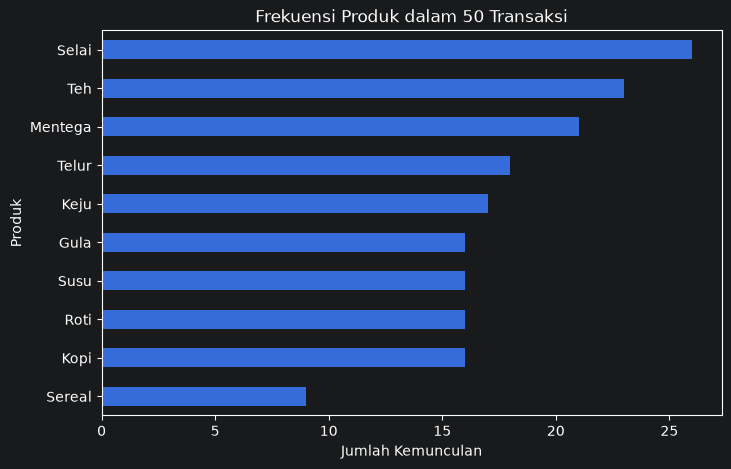

In [17]:
frekuensi = pd.Series(
    [item for trx in transaksi for item in trx]
).value_counts()

print('Frekuensi produk:')
display(frekuensi.to_frame('jumlah'))

plt.figure(figsize=(8, 5))
frekuensi.sort_values().plot(kind='barh')
plt.xlabel('Jumlah Kemunculan')
plt.ylabel('Produk')
plt.title('Frekuensi Produk dalam 50 Transaksi')
plt.show()


## One-Hot Encoding Transaksi

In [18]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)

df = pd.DataFrame(
    te_ary,
    columns=te.columns_
)

print('Shape data one-hot:', df.shape)
display(df.head())


Shape data one-hot: (50, 10)


,Gula,Keju,Kopi,Mentega,Roti,Selai,Sereal,Susu,Teh,Telur
0,False,True,True,True,True,True,False,False,False,False
1,False,False,True,True,True,True,False,False,True,False
2,False,False,True,False,False,False,False,True,True,False
3,False,True,False,False,False,True,False,False,True,True
4,True,True,False,True,False,False,False,True,False,False


## Cari Frequent Itemset dengan Apriori

In [19]:
from mlxtend.frequent_patterns import apriori

for ms in [0.05, 0.1, 0.2]:
    freq = apriori(
        df,
        min_support=ms,
        use_colnames=True
    )
    print(
        f'min_support={ms}: '
        f'{len(freq)} itemset ditemukan'
    )


min_support=0.05: 74 itemset ditemukan
min_support=0.1: 44 itemset ditemukan
min_support=0.2: 13 itemset ditemukan


In [20]:
freq_items = apriori(
    df,
    min_support=0.1,
    use_colnames=True
)

freq_items = freq_items.sort_values(
    'support',
    ascending=False
)

print('10 frequent itemset dengan support tertinggi:')
display(freq_items.head(10))


10 frequent itemset dengan support tertinggi:


,support,itemsets
5,0.52,frozenset({Selai})
8,0.46,frozenset({Teh})
3,0.42,frozenset({Mentega})
9,0.36,frozenset({Telur})
1,0.34,frozenset({Keju})
0,0.32,frozenset({Gula})
2,0.32,frozenset({Kopi})
4,0.32,frozenset({Roti})
7,0.32,frozenset({Susu})
36,0.24,"frozenset({Selai, Teh})"


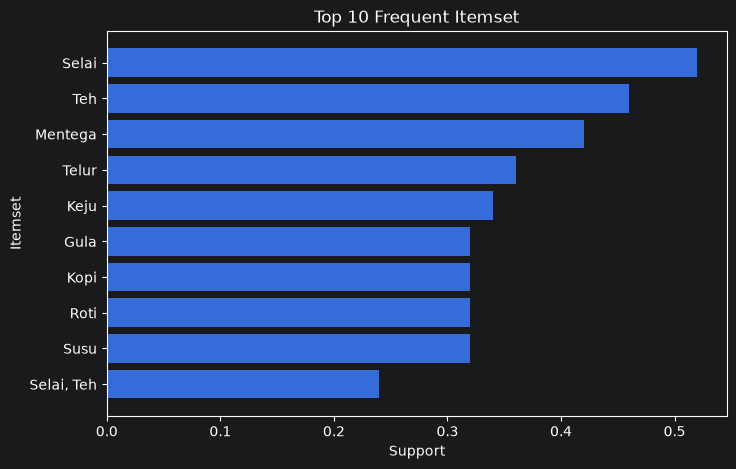

In [21]:
# Visualisasi Top 10 Frequent Itemset
top_itemsets = freq_items.head(10).copy()
top_itemsets['itemsets_str'] = top_itemsets['itemsets'].apply(
    lambda x: ', '.join(sorted(list(x)))
)

plt.figure(figsize=(8, 5))
plt.barh(
    top_itemsets['itemsets_str'][::-1],
    top_itemsets['support'][::-1]
)
plt.xlabel('Support')
plt.ylabel('Itemset')
plt.title('Top 10 Frequent Itemset')
plt.show()


## Bentuk & Saring Aturan Asosiasi

In [22]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    freq_items,
    metric='confidence',
    min_threshold=0.5
)

rules = (
    rules[rules['lift'] > 1]
    .sort_values('lift', ascending=False)
)

kolom_tampil = [
    'antecedents',
    'consequents',
    'support',
    'confidence',
    'lift'
]

print('10 aturan asosiasi dengan Lift tertinggi:')
display(rules[kolom_tampil].head(10))


10 aturan asosiasi dengan Lift tertinggi:


,antecedents,consequents,support,confidence,lift
8,"frozenset({Teh, Keju})",frozenset({Telur}),0.12,0.857143,2.380952
13,"frozenset({Mentega, Selai})",frozenset({Kopi}),0.10,0.625000,1.953125
12,"frozenset({Roti, Gula})",frozenset({Selai}),0.10,1.000000,1.923077
7,frozenset({Sereal}),frozenset({Mentega}),0.14,0.777778,1.851852
9,"frozenset({Teh, Telur})",frozenset({Keju}),0.12,0.600000,1.764706
15,"frozenset({Selai, Kopi})",frozenset({Mentega}),0.10,0.714286,1.700680
10,"frozenset({Keju, Telur})",frozenset({Teh}),0.12,0.750000,1.630435
11,"frozenset({Selai, Gula})",frozenset({Roti}),0.10,0.500000,1.562500
14,"frozenset({Mentega, Kopi})",frozenset({Selai}),0.10,0.714286,1.373626
1,frozenset({Roti}),frozenset({Selai}),0.22,0.687500,1.322115


## Rekomender Sederhana dengan Content-Based Filtering

In [23]:
from sklearn.metrics.pairwise import cosine_similarity

katalog = pd.DataFrame({
    'produk': produk,
    'kategori': [
        'Bakery', 'Bakery', 'Dairy', 'Bakery', 'Dairy',
        'Dairy', 'Minuman', 'Bumbu', 'Minuman', 'Dairy'
    ]
})

print('Katalog produk:')
display(katalog)

fitur = pd.get_dummies(katalog['kategori'])
sim_matrix = cosine_similarity(fitur)

display(
    pd.DataFrame(
        sim_matrix,
        index=katalog['produk'],
        columns=katalog['produk']
    )
)


Katalog produk:


,produk,kategori
0,Roti,Bakery
1,Selai,Bakery
2,Susu,Dairy
3,Sereal,Bakery
4,Telur,Dairy
5,Keju,Dairy
6,Kopi,Minuman
7,Gula,Bumbu
8,Teh,Minuman
9,Mentega,Dairy


produk,Roti,Selai,Susu,Sereal,Telur,Keju,Kopi,Gula,Teh,Mentega
produk,,,,,,,,,,
Roti,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Selai,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Susu,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
Sereal,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Telur,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
Keju,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
Kopi,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
Gula,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
Teh,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [24]:
def rekomendasi_serupa(nama_produk, top_n=3):
    idx = katalog.index[
        katalog['produk'] == nama_produk
    ][0]

    skor = list(enumerate(sim_matrix[idx]))
    skor = sorted(
        skor,
        key=lambda x: x[1],
        reverse=True
    )

    # Hilangkan produk itu sendiri
    skor = [
        s for s in skor
        if s[0] != idx
    ][:top_n]

    hasil = katalog.iloc[
        [i for i, _ in skor]
    ]['produk'].tolist()

    return hasil

print(
    'Mirip dengan Roti:',
    rekomendasi_serupa('Roti')
)


Mirip dengan Roti: ['Selai', 'Sereal', 'Susu']


## Bandingkan Kedua Pendekatan

In [25]:
produk_target = 'Roti'

# Association Rules:
# cari rules yang antecedent-nya mengandung produk target
rules_terkait = rules[
    rules['antecedents'].apply(
        lambda x: produk_target in x
    )
]

print('Rekomendasi dari Association Rules:')
display(
    rules_terkait[
        ['antecedents', 'consequents', 'confidence', 'lift']
    ].head()
)

print(
    'Rekomendasi dari Content-Based:',
    rekomendasi_serupa(produk_target)
)


Rekomendasi dari Association Rules:


,antecedents,consequents,confidence,lift
12,"frozenset({Roti, Gula})",frozenset({Selai}),1.0000,1.923077
1,frozenset({Roti}),frozenset({Selai}),0.6875,1.322115


Rekomendasi dari Content-Based: ['Selai', 'Sereal', 'Susu']


## Kesimpulan

Algoritma Apriori berhasil menemukan frequent itemset dan aturan asosiasi dari 50 transaksi sintetis. Dengan `min_support=0.10`, aturan yang memiliki Lift tinggi menunjukkan kombinasi produk yang lebih sering muncul bersama dibandingkan secara kebetulan, termasuk pola **Roti → Selai** yang sengaja ditanamkan pada dataset. Content-Based Filtering menghasilkan rekomendasi berdasarkan kesamaan kategori produk melalui cosine similarity. Kedua metode memiliki dasar rekomendasi yang berbeda, sehingga pendekatan hybrid dapat memberikan hasil yang lebih lengkap dengan menggabungkan pola transaksi dan atribut produk.
